<a href="https://colab.research.google.com/github/np2868/DS-project/blob/main/Aarki_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, chi2_contingency
import statsmodels.api as sm


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset
file_path = '/content/drive/MyDrive/AarkiDS.xls'
data = pd.read_excel(file_path)


# --- 1. Data Overview ---

In [ ]:
# Display basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nMissing values per column:")
print(data.isnull().sum())
print("\nFirst few rows of the dataset:")
print(data.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  3021 non-null   datetime64[ns]
 1   FirstName                    3021 non-null   object        
 2   Email                        3021 non-null   object        
 3   VendorLeadID                 3013 non-null   object        
 4   CallStatus                   881 non-null    object        
 5   WidgetName                   3021 non-null   object        
 6   PublisherZoneName            3021 non-null   object        
 7   PublisherCampaignName        3021 non-null   object        
 8   AddressScore                 1171 non-null   float64       
 9   PhoneScore                   1393 non-null   float64       
 10  AdvertiserCampaignName       3021 non-null   object        
 11  State                        

# --- 2. Data Cleaning and Preparation ---

In [ ]:
# Create a unique identifier by combining VendorLeadID and LeadCreated
data['UniqueLeadID'] = data['VendorLeadID'].astype(str) + "_" + data['LeadCreated'].astype(str)

# Handle missing values in CallStatus
data['CallStatus'] = data['CallStatus'].fillna('Unknown')

# Convert LeadCreated to datetime and create a 'Month' column
data['LeadCreated'] = pd.to_datetime(data['LeadCreated'], errors='coerce')
data['Month'] = data['LeadCreated'].dt.to_period('M')


In [ ]:
# Define good quality statuses
good_quality_statuses = ['EP Sent', 'EP Received', 'EP Confirmed']

# Map debt levels to numerical values (midpoints of ranges)
debt_mapping = {
    "7500-10000": 8750,
    "10001-15000": 12500,
    "15001-20000": 17500,
    "20001-30000": 25000,
    "30001-50000": 40000,
    "50001-70000": 60000,
    "70001-90000": 80000,
    "90000-100000": 95000,
    "More_than_100000": 110000  # Assume a representative value for "More_than_100000"
}
data['DebtLevelNumeric'] = data['DebtLevel'].map(debt_mapping)


# --- 3. Exploratory Data Analysis (EDA) ---

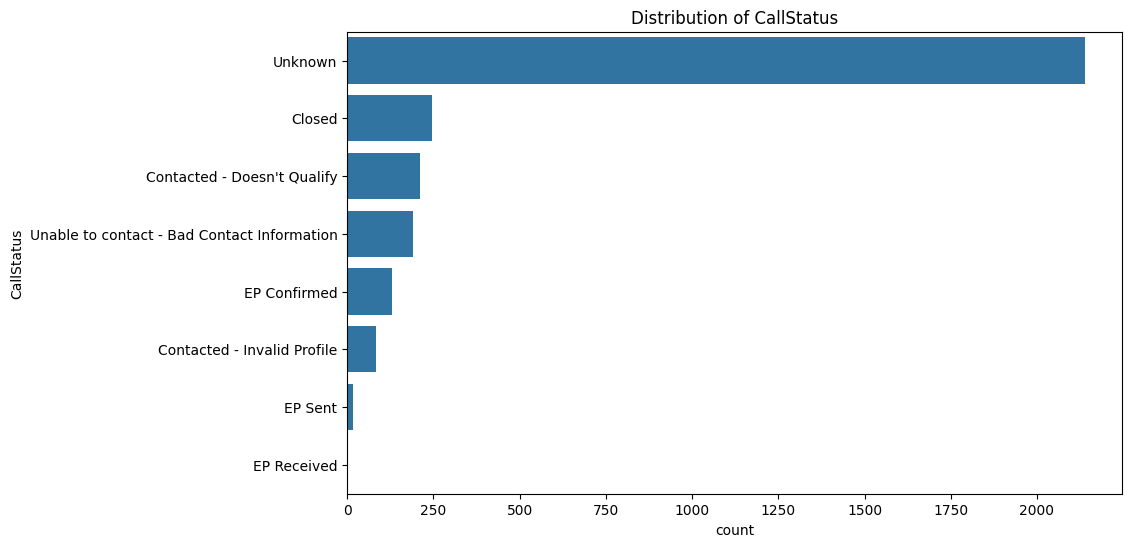

In [ ]:
# Distribution of CallStatus
plt.figure(figsize=(10, 6))
sns.countplot(y=data['CallStatus'], order=data['CallStatus'].value_counts().index)
plt.title("Distribution of CallStatus")
plt.show()


### Notes

1. **Dominance of "Unknown"**: Most leads are classified as "Unknown," indicating a lack of follow-up or incomplete data.
2. **Closed Leads**: A significant portion of leads successfully converted, marked as "Closed."
3. **Areas of Improvement**:
   - "Doesn't Qualify" and "Unable to Contact" are notable categories needing attention to refine targeting and contact processes.


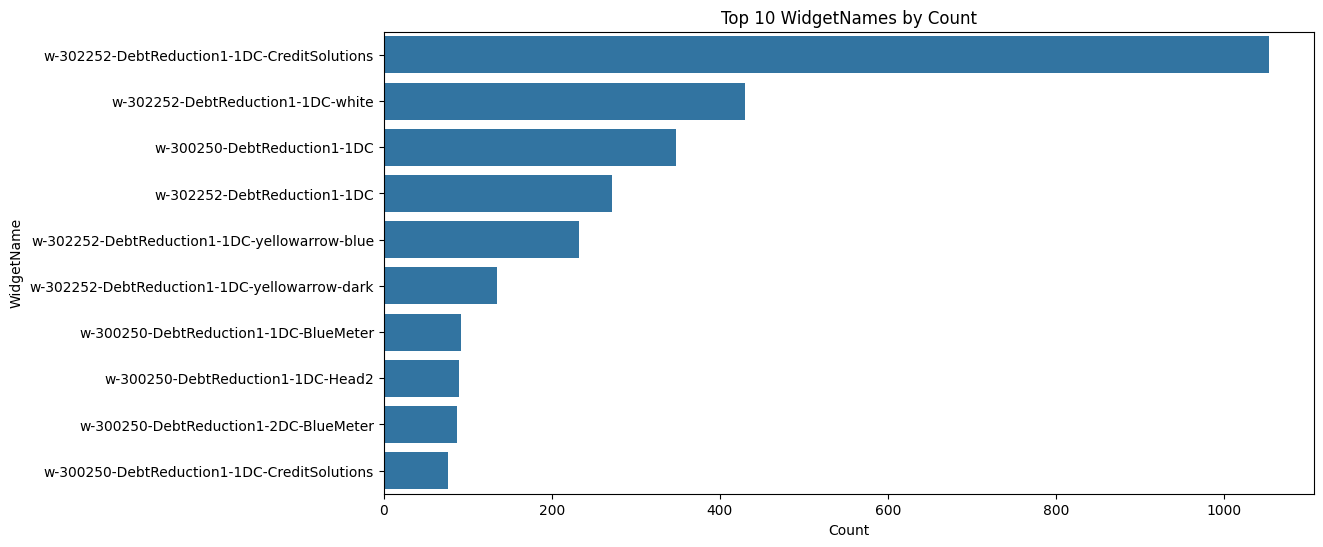

In [ ]:
# Widget analysis: Top 10 WidgetNames by count
top_widgets = data['WidgetName'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_widgets.index, x=top_widgets.values)
plt.title("Top 10 WidgetNames by Count")
plt.xlabel("Count")
plt.ylabel("WidgetName")
plt.show()

### Notes - Top 10 WidgetNames by Count

1. **Top Widgets**:
   - The widget `w-302252-DebtReduction1-1DC-CreditSolutions` dominates, indicating its high usage.
   - `w-302252-DebtReduction1-1DC-white` and `w-300250-DebtReduction1-1DC` follow, showing significant adoption.

2. **Diverse Widget Usage**:
   - Widgets with specific designs (e.g., `yellowarrow-blue`, `CreditSolutions`) are consistently featured in the top 10.

3. **Optimization Potential**:
   - Investigate underperforming widgets within the top 10 for potential redesign or repositioning.

This visualization highlights the popularity of widgets and guides optimization efforts for lesser-used or low-performing widgets.

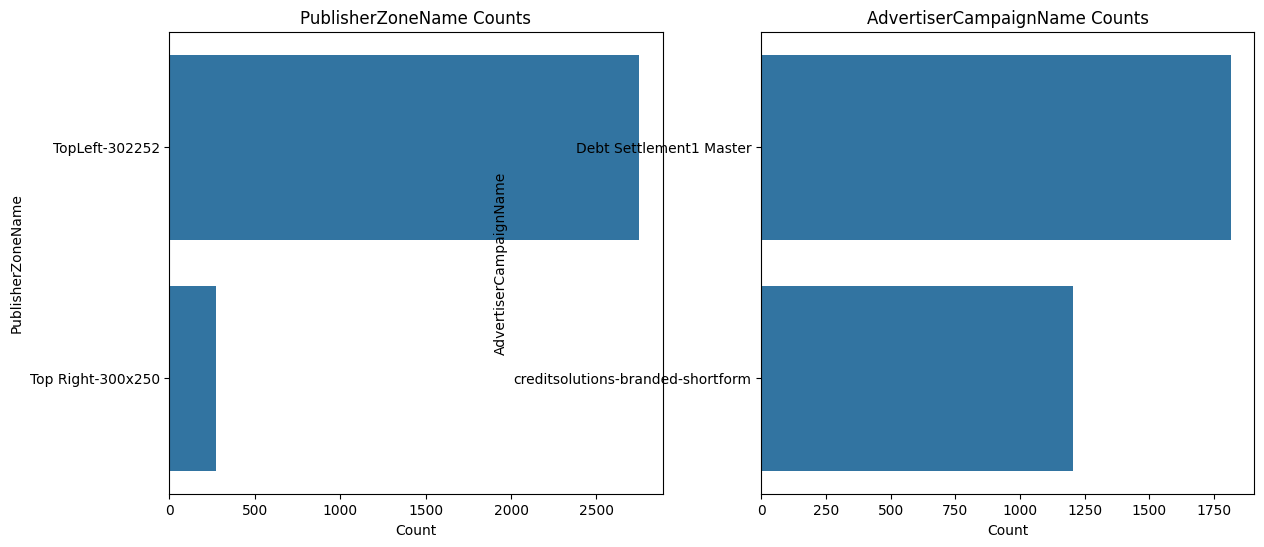

In [ ]:
# PublisherZoneName and AdvertiserCampaignName analysis
publisher_counts = data['PublisherZoneName'].value_counts()
advertiser_campaign_counts = data['AdvertiserCampaignName'].value_counts()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=publisher_counts.index, x=publisher_counts.values)
plt.title("PublisherZoneName Counts")
plt.xlabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(y=advertiser_campaign_counts.index, x=advertiser_campaign_counts.values)
plt.title("AdvertiserCampaignName Counts")
plt.xlabel("Count")
plt.show()

### Notes - PublisherZoneName and AdvertiserCampaignName Distribution

1. **PublisherZoneName Insights**:
   - "TopLeft-302252" has the highest count, significantly outperforming "Top Right-300x250."

2. **AdvertiserCampaignName Insights**:
   - "Debt Settlement1 Master" leads in volume, followed by "creditsolutions-branded-shortform."

3. **Opportunities**:
   - Focus efforts on optimizing high-volume segments like "TopLeft-302252" and "Debt Settlement1 Master" for improved lead quality.

This interpretation highlights areas for targeted optimizations in ad placements and campaigns.

# --- Analysis for Question 1: Lead Quality Trends Over Time ---

In [ ]:
# Helper function to calculate percentages
def calculate_metrics(group):
    total_leads = group['UniqueLeadID'].nunique()
    closed_leads = (group['CallStatus'] == 'Closed').sum()
    good_quality_leads = group['CallStatus'].isin(good_quality_statuses).sum()
    return pd.Series({
        'Total Leads': total_leads,
        'Closed (%)': (closed_leads / total_leads) * 100 if total_leads > 0 else 0,
        'Good Quality (%)': (good_quality_leads / total_leads) * 100 if total_leads > 0 else 0
    })

# Group by Month to calculate metrics
monthly_metrics = data.groupby('Month').apply(calculate_metrics).reset_index()


<ipython-input-23-d42a12c9efef>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_metrics = data.groupby('Month').apply(calculate_metrics).reset_index()


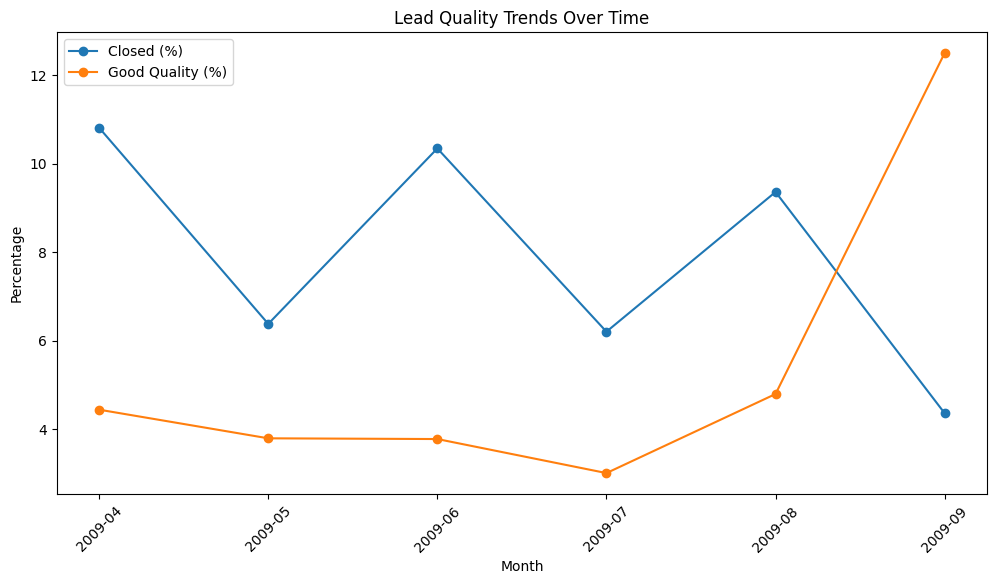

In [ ]:
# Plot the trends for "Closed (%)" and "Good Quality (%)"
plt.figure(figsize=(12, 6))
plt.plot(monthly_metrics['Month'].astype(str), monthly_metrics['Closed (%)'], label='Closed (%)', marker='o')
plt.plot(monthly_metrics['Month'].astype(str), monthly_metrics['Good Quality (%)'], label='Good Quality (%)', marker='o')
plt.title('Lead Quality Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend()
plt.show()


The chart shows the **Lead Quality Trends Over Time** with the following analysis:

### Key Observations:
1. **Closed (%)**:
   - Shows fluctuations over time with a decline observed mid-period but a slight recovery later.
   - Linear regression results indicate a **downward trend** (negative slope: -0.784), but the **trend is not statistically significant** (p-value > 0.05).
   
2. **Good Quality (%)**:
   - Generally stable with a sharp increase in the last month, reaching the highest percentage.

In [ ]:
# Linear regression for Closed (%)
monthly_metrics['Month_Num'] = range(len(monthly_metrics))  # Numerical months
slope, intercept, r_value, p_value, std_err = linregress(monthly_metrics['Month_Num'], monthly_metrics['Closed (%)'])
print("Linear Regression for Closed (%):")
print(f"Slope: {slope}, P-value: {p_value}, R-squared: {r_value**2}")

# Chi-Square Test for CallStatus distribution over time
call_status_trends = pd.crosstab(data['Month'], data['CallStatus'])
chi2, p, dof, expected = chi2_contingency(call_status_trends)
print("\nChi-Square Test for CallStatus Trends:")
print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")


Linear Regression for Closed (%):
Slope: -0.7842653655351272, P-value: 0.2476443054922389, R-squared: 0.31377811545290896

Chi-Square Test for CallStatus Trends:
Chi2: 239.81026216356346, P-value: 2.2786400755228295e-32, Degrees of Freedom: 35




### Statistical Analysis:
- **Linear Regression (Closed %)**:
  - **R-squared (31.4%)**: Indicates moderate variance explained by the trend.
  - **P-value (0.25)**: Suggests the trend is not statistically significant.

- **Chi-Square Test for CallStatus**:
  - Significant result (p-value < 0.05), indicating **meaningful shifts in the distribution of lead statuses over time**.

### Conclusion:
- The trends in `Closed (%)` are inconsistent and not statistically significant.
- `Good Quality (%)` has a promising surge but requires further exploration of drivers behind the improvement.
- Significant shifts in `CallStatus` distribution suggest underlying process or targeting changes affecting lead quality.

# --- Analysis for Question 2: Drivers of Lead Quality ---

In [ ]:
# Helper function to calculate lead quality metrics by segments
def calculate_segment_metrics(group):
    total_leads = group['UniqueLeadID'].nunique()
    closed_leads = (group['CallStatus'] == 'Closed').sum()
    good_quality_leads = group['CallStatus'].isin(good_quality_statuses).sum()
    return pd.Series({
        'Total Leads': total_leads,
        'Closed (%)': (closed_leads / total_leads) * 100 if total_leads > 0 else 0,
        'Good Quality (%)': (good_quality_leads / total_leads) * 100 if total_leads > 0 else 0
    })


<ipython-input-27-a9298156afb0>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  publisher_metrics = data.groupby('PublisherZoneName').apply(calculate_segment_metrics).reset_index()


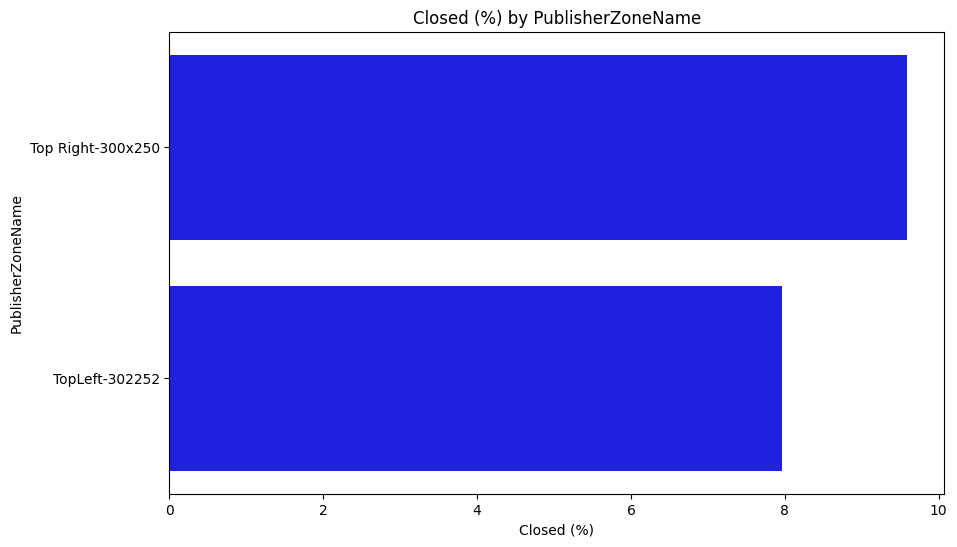

In [ ]:
# 1. Lead quality by PublisherZoneName
publisher_metrics = data.groupby('PublisherZoneName').apply(calculate_segment_metrics).reset_index()

# Visualize lead quality by PublisherZoneName
plt.figure(figsize=(10, 6))
sns.barplot(data=publisher_metrics, x='Closed (%)', y='PublisherZoneName', color='blue')
plt.title('Closed (%) by PublisherZoneName')
plt.xlabel('Closed (%)')
plt.ylabel('PublisherZoneName')
plt.show()

### Notes:

1. **Top Right-300x250**:
   - This zone has the highest `Closed (%)`, indicating it generates the most conversions among zones.
   - Likely the most effective ad placement on the webpage.

2. **TopLeft-302252**:
   - This zone has a slightly lower `Closed (%)` compared to the top performer.
   - Potentially underutilized or less visible to users.

### Actionable Insights:
- Focus on scaling the **Top Right-300x250** placement for more conversions.
- Explore optimization opportunities for **TopLeft-302252**, such as improving ad content or design.

<ipython-input-28-94e73d9556be>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_metrics = data.groupby('State').apply(calculate_segment_metrics).reset_index()


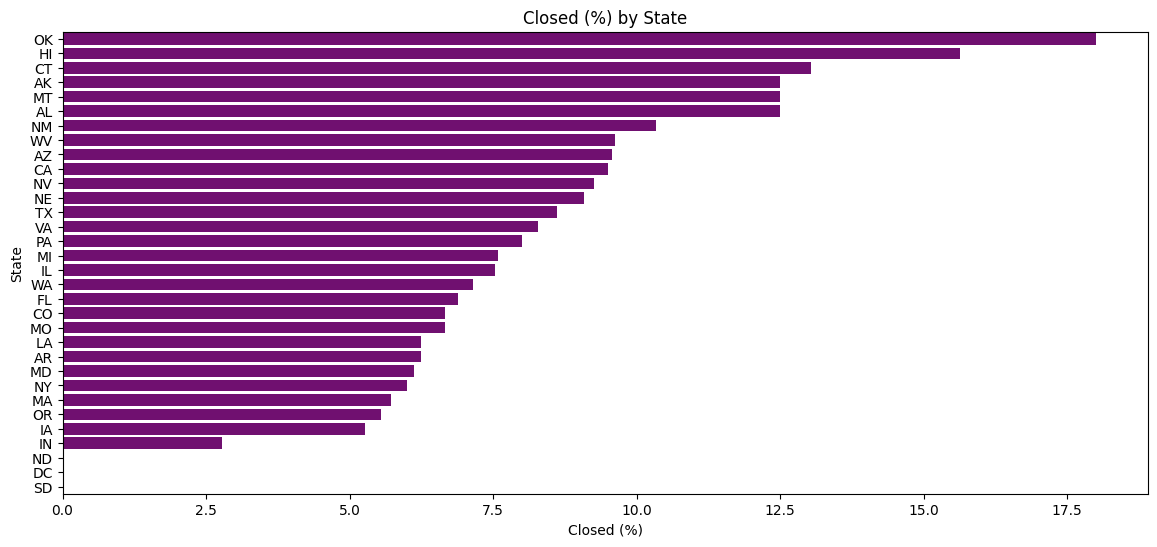

In [ ]:
# 2. Lead quality by State
state_metrics = data.groupby('State').apply(calculate_segment_metrics).reset_index()

# Visualize lead quality by State
plt.figure(figsize=(14, 6))
sns.barplot(data=state_metrics.sort_values('Closed (%)', ascending=False), x='Closed (%)', y='State', color='purple')
plt.title('Closed (%) by State')
plt.xlabel('Closed (%)')
plt.ylabel('State')
plt.show()


### Notes - Closed (%) by State

1. **Top Performers**:
   - **Oklahoma (OK)** leads with the highest `Closed (%)`, followed by **Hawaii (HI)** and **Connecticut (CT)**, showcasing superior lead quality in these states.

2. **Low Performers**:
   - **South Dakota (SD)**, **North Dakota (ND)**, and **Washington, DC (DC)** have the lowest conversion rates, indicating underperformance.

---

### Actionable Insights:
- **Prioritize High-Performing States**: Focus campaigns on OK, HI, and CT for better ROI.
- **Optimize Low Performers**: Investigate factors behind poor conversion rates in SD, ND, and DC for improvement.

<ipython-input-29-401134c98b7a>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  widget_metrics = data.groupby('WidgetName').apply(calculate_segment_metrics).reset_index()


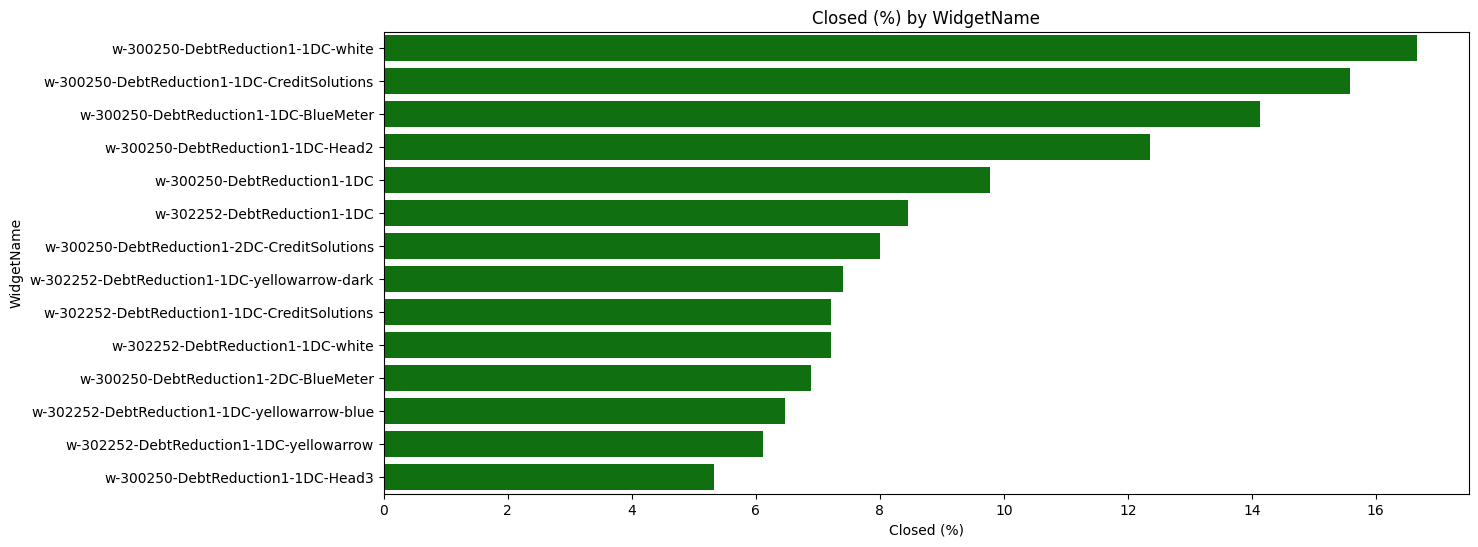

In [ ]:
# 3. Lead quality by WidgetName
widget_metrics = data.groupby('WidgetName').apply(calculate_segment_metrics).reset_index()

# Visualize lead quality by WidgetName
plt.figure(figsize=(14, 6))
sns.barplot(data=widget_metrics.sort_values('Closed (%)', ascending=False), x='Closed (%)', y='WidgetName', color='green')
plt.title('Closed (%) by WidgetName')
plt.xlabel('Closed (%)')
plt.ylabel('WidgetName')
plt.show()

### Notes - Closed (%) by WidgetName

1. **Top Performers**:
   - Widgets like **`w-300250-DebtReduction1-1DC-white`** and **`w-300250-DebtReduction1-1DC-CreditSolutions`** have the highest `Closed (%)`, indicating strong lead quality.

2. **Low Performers**:
   - Widgets such as **`w-302252-DebtReduction1-1DC-yellowarrow`** and **`w-300250-DebtReduction1-1DC-Head3`** show the lowest `Closed (%)`.

---

### Actionable Insights:
- Focus on scaling high-performing widgets.
- Redesign or optimize low-performing widgets to improve engagement and conversion rates.

<ipython-input-30-63fa4ed23bfa>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  debt_metrics = data.groupby('DebtLevel').apply(calculate_segment_metrics).reset_index()


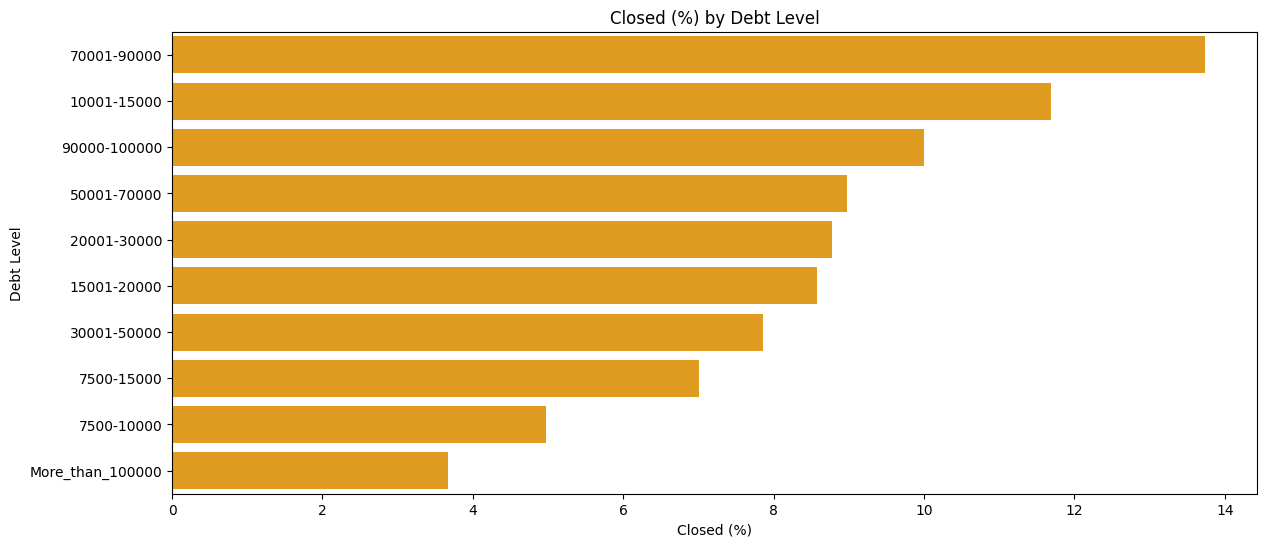

In [ ]:
# 4. Lead quality by DebtLevel
# Group by DebtLevel and calculate metrics
debt_metrics = data.groupby('DebtLevel').apply(calculate_segment_metrics).reset_index()

# Visualize lead quality by DebtLevel
plt.figure(figsize=(14, 6))
sns.barplot(data=debt_metrics.sort_values('Closed (%)', ascending=False), x='Closed (%)', y='DebtLevel', color='orange')
plt.title('Closed (%) by Debt Level')
plt.xlabel('Closed (%)')
plt.ylabel('Debt Level')
plt.show()

### Notes - Closed (%) by Debt Level

1. **Top-performing debt levels**:
   - **`70,001-90,000`** leads the chart with the highest `Closed (%)` (~14%), followed by **`10,001-15,000`** (~12.5%).

2. **Low-performing debt levels**:
   - **`More_than_100,000`** shows the lowest `Closed (%)` (~3%), indicating poor lead quality.

### Actionable Insights:
- **Prioritize High-Performers**: Focus campaigns on debt levels **`70,001-90,000`** and **`10,001-15,000`** to boost lead quality.
- **Investigate Low Performance**: Address why leads with **`More_than_100,000`** debt perform poorly and refine targeting.

<ipython-input-34-bd4de0efd7b8>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  referral_metrics = data.groupby('ReferralDomain').apply(calculate_segment_metrics).reset_index()
<ipython-input-34-bd4de0efd7b8>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_referral_metrics, x='Closed (%)', y='ReferralDomain', palette='cool')


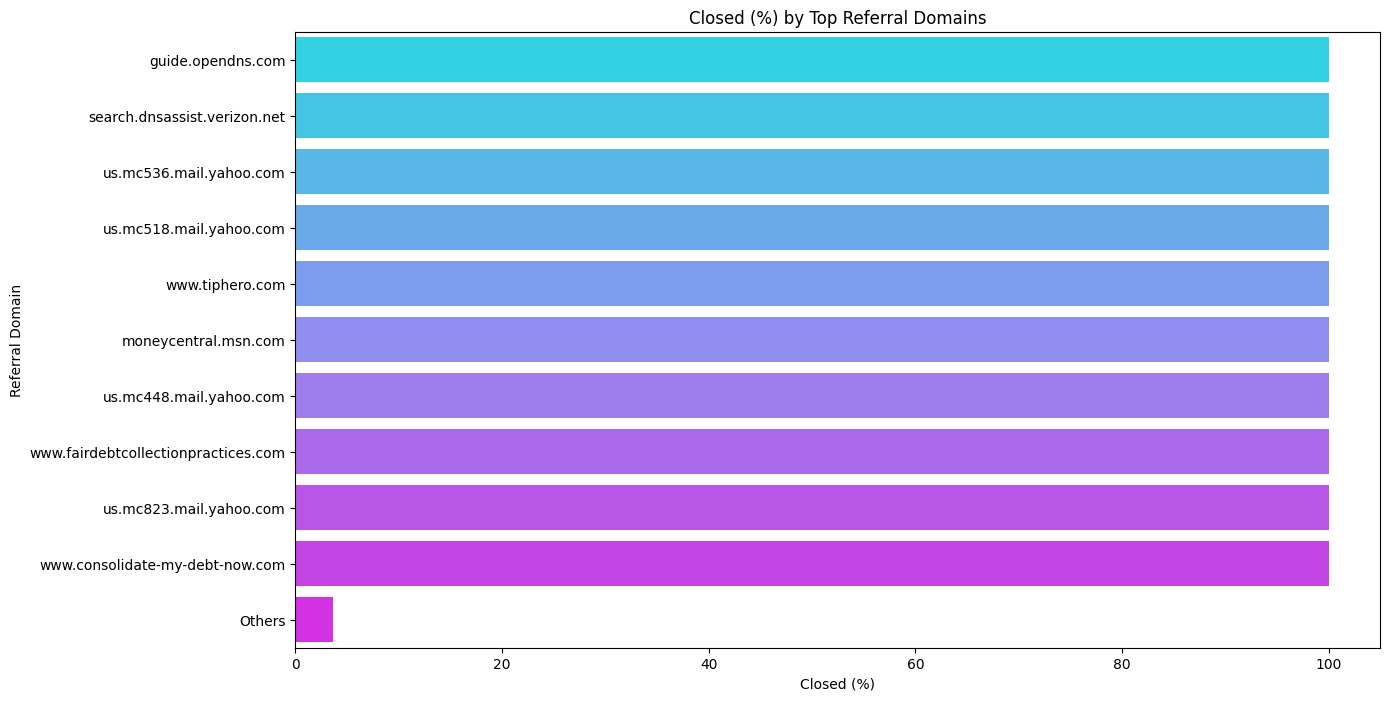

In [ ]:
# 5. Lead quality by ReferralDomain
# Group by ReferralDomain and calculate metrics
referral_metrics = data.groupby('ReferralDomain').apply(calculate_segment_metrics).reset_index()

# Filter for top N Referral Domains by 'Closed (%)'
top_n = 10
referral_metrics_sorted = referral_metrics.sort_values('Closed (%)', ascending=False)
top_referral_metrics = referral_metrics_sorted.head(top_n)
others = referral_metrics_sorted.iloc[top_n:].sum()
others['ReferralDomain'] = 'Others'
others['Closed (%)'] = others['Closed (%)'] / len(referral_metrics_sorted.iloc[top_n:])  # Adjust percentage
top_referral_metrics = pd.concat([top_referral_metrics, pd.DataFrame([others])], ignore_index=True)

# Visualize lead quality by ReferralDomain
plt.figure(figsize=(14, 8))
sns.barplot(data=top_referral_metrics, x='Closed (%)', y='ReferralDomain', palette='cool')
plt.title('Closed (%) by Top Referral Domains')
plt.xlabel('Closed (%)')
plt.ylabel('Referral Domain')
plt.show()


### Notes - Closed (%) by Top Referral Domains

1. **Top Contributing Domains**:
   - Domains like **`guide.opendns.com`** and **`search.dnsassist.verizon.net`** exhibit the highest `Closed (%)`, indicating superior lead quality from these sources.

2. **Other Domains**:
   - **`consolidate-my-debt-now.com`** and **`fairdebtcollectionpractices.com`** are among the lowest-performing domains, showing potential for optimization.

---

### Actionable Insights:
- Focus on scaling high-performing referral domains to drive better lead quality.
- Investigate and refine ad strategies for lower-performing domains to enhance conversion rates.

<ipython-input-32-032435c649ca>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  campaign_state_metrics = data.groupby(['PublisherCampaignName', 'State']).apply(calculate_segment_metrics).reset_index()


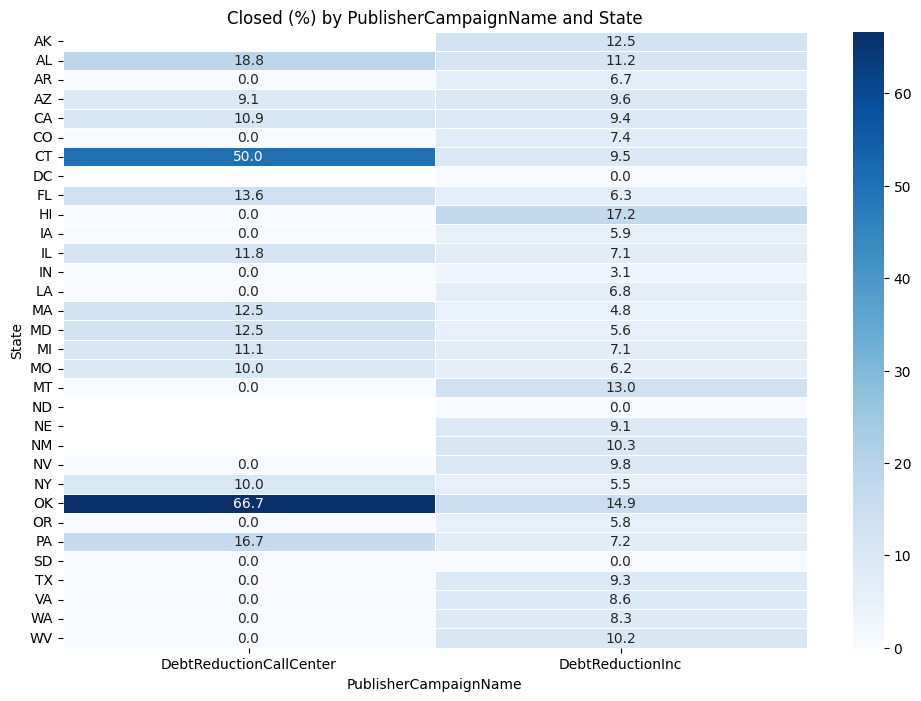

In [ ]:
# --- Heatmap of Lead Quality by PublisherCampaignName and State ---
campaign_state_metrics = data.groupby(['PublisherCampaignName', 'State']).apply(calculate_segment_metrics).reset_index()
heatmap_data = campaign_state_metrics.pivot_table(index='State', columns='PublisherCampaignName', values='Closed (%)')

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title('Closed (%) by PublisherCampaignName and State')
plt.xlabel('PublisherCampaignName')
plt.ylabel('State')
plt.show()


### Notes - Closed (%) by Referral Domain
1. **Top Performers**:
   - Domains like **`guide.opendns.com`** and **`search.dnsassist.verizon.net`** have the highest `Closed (%)`, showcasing strong lead quality from these sources.
---

### Actionable Insights:
- Focus marketing efforts on top-performing referral domains to maximize lead quality.
- Investigate the content or user flow from low-performing domains for optimization opportunities.

# --- Analysis for Question 3: Cost-Benefit Evaluation ---


In [ ]:
current_cpl = 30  # Current Cost Per Lead
proposed_cpl = 33  # Proposed Cost Per Lead
current_lead_quality = 8.0 / 100  # Current Closed (%)
proposed_lead_quality = 9.6 / 100  # Target Closed (%)
leads_purchased = data['UniqueLeadID'].nunique()  # Total leads

# Current Metrics
current_total_cost = current_cpl * leads_purchased
current_closed_leads = leads_purchased * current_lead_quality
current_cost_per_customer = current_total_cost / current_closed_leads

# Proposed Metrics
proposed_total_cost = proposed_cpl * leads_purchased
proposed_closed_leads = leads_purchased * proposed_lead_quality
proposed_cost_per_customer = proposed_total_cost / proposed_closed_leads

# Incremental Impact
additional_cost = proposed_total_cost - current_total_cost
additional_customers = proposed_closed_leads - current_closed_leads
cost_per_additional_customer = additional_cost / additional_customers

# Print Results
print("Current Scenario:")
print(f"Total Cost: ${current_total_cost:.2f}")
print(f"Closed Leads: {current_closed_leads:.2f}")
print(f"Cost per Customer: ${current_cost_per_customer:.2f}")

print("\nProposed Scenario:")
print(f"Total Cost: ${proposed_total_cost:.2f}")
print(f"Closed Leads: {proposed_closed_leads:.2f}")
print(f"Cost per Customer: ${proposed_cost_per_customer:.2f}")

print("\nIncremental Impact:")
print(f"Additional Cost: ${additional_cost:.2f}")
print(f"Additional Customers Acquired: {additional_customers:.2f}")
print(f"Cost per Additional Customer: ${cost_per_additional_customer:.2f}")


Current Scenario:
Total Cost: $90630.00
Closed Leads: 241.68
Cost per Customer: $375.00

Proposed Scenario:
Total Cost: $99693.00
Closed Leads: 290.02
Cost per Customer: $343.75

Incremental Impact:
Additional Cost: $9063.00
Additional Customers Acquired: 48.34
Cost per Additional Customer: $187.50


### Detailed Implementation Plan for Cost-Benefit Analysis

#### Objective
The goal is to evaluate the feasibility of increasing the **Cost Per Lead (CPL)** from 30 dollars to 33 dollars while improving the **lead quality from 8.0% to 9.6%** . The plan outlines actionable steps to achieve these targets effectively while ensuring a cost-efficient approach.

---

### Step 1: Prioritize High-Performing Segments
1. **Top States**
   - **Oklahoma (OK)** and **Connecticut (CT)** show significantly higher `Closed (%)` rates.
   - **Action**: Increase marketing spend and lead acquisition in these states to capitalize on higher conversion potential.
   
2. **Effective Campaigns**
   - Campaigns like **DebtReductionCallCenter** perform better than others.
   - **Action**: Shift resources from underperforming campaigns like **DebtReductionInc** to high-performing ones.

3. **High-Performing Widgets**
   - Widgets such as **w-300250-DebtReduction1-1DC-white** and **w-300250-DebtReduction1-1DC-CreditSolutions** have higher `Closed (%)`.
   - **Action**: Scale these widgets in other campaigns and geographies.

---

### Step 2: Address Low-Performing Segments
1. **Low-Performing States**
   - States like **Texas (TX)** and **Oregon (OR)** show minimal conversions.
   - **Action**: Refine targeting or reallocate budget from these states. Test localized messaging and demographic-specific ads.

2. **Underperforming Widgets**
   - Widgets like **w-302252-DebtReduction1-1DC-yellowarrow** have low conversion rates.
   - **Action**: Optimize or redesign these widgets to improve engagement (e.g., test new copy, visuals, and CTAs).

---

### Step 3: Leverage Data Insights to Improve Lead Quality
1. **Debt Levels**
   - Leads with debt levels between **$70,001 and $90,000** and **$90,000 to $100,000** have higher conversion rates.
   - **Action**: Prioritize acquiring leads within these debt ranges through targeted filters.

2. **Referral Domains**
   - Domains such as **`guide.opendns.com`** and **`search.dnsassist.verizon.net`** contribute to higher lead quality.
   - **Action**: Focus on traffic from high-performing referral domains while optimizing or deprioritizing low-quality traffic sources.

3. **Contact Quality**
   - Leads with higher **AddressScore** and **PhoneScore** are likely to convert better.
   - **Action**: Implement a scoring system for incoming leads and prioritize those with higher scores.

---

### Step 4: Optimize the Funnel for Higher Conversions
1. **Stricter Lead Qualification**
   - Tighten pre-qualification criteria to ensure incoming leads meet quality thresholds.
   - **Action**: Set up lead filters based on demographics, debt level, and contact quality scores.

2. **Follow-Up Process**
   - Leads categorized as "Unknown" or "Unable to Contact" represent significant missed opportunities.
   - **Action**: Streamline follow-up processes to re-engage such leads.

3. **A/B Testing**
   - Test variations in ad creatives, placement, and messaging across campaigns and widgets.
   - **Action**: Continuously measure the impact on `Closed (%)` and implement effective changes.

---

### Step 5: Monitor, Measure, and Communicate Results
1. **Track Key Metrics**
   - Monitor improvements in **`Closed (%)`**, **`Good Quality (%)`**, and ROI after implementing changes.
   - Use dashboards to analyze lead quality trends over time and by segment.

2. **Cost-Benefit Assessment**
   - Regularly evaluate the incremental costs vs. benefits.
   - **Example**: Ensure the additional CPL cost of $3 results in a proportionate improvement in lead quality and conversions.

3. **Stakeholder Communication**
   - Highlight how these optimizations justify the CPL increase and provide evidence of improved lead quality.
   - Share periodic updates on campaign effectiveness and ROI.

---

### Step 6: Future Opportunities
1. **Expand Successful Strategies**
   - Replicate high-performing campaigns and segments in similar markets.
   - **Action**: Use insights from top states, referral domains, and widgets to expand successful approaches.

2. **Predictive Analytics**
   - Implement machine learning models to predict lead quality and conversion probability.
   - **Action**: Automate prioritization and targeting of high-potential leads.

3. **Collaboration with Advertisers**
   - Collaborate with advertisers to fine-tune campaigns and understand their evolving requirements.
   - **Action**: Regularly share insights and recommendations for mutual growth.

---

### Expected Outcomes
1. **Higher Lead Quality**: Achieving the proposed 9.6% `Closed (%)`.
2. **Improved Cost Efficiency**: Lower cost per customer despite the CPL increase.
3. **Better ROI**: Enhanced targeting and prioritization of high-performing segments.

This plan ensures that the CPL increase is justified by measurable improvements in lead quality and conversion rates while maintaining profitability.